In [12]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [13]:
data=pd.read_csv('Data\Cleaned_data')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [14]:
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 

In [15]:
x=data.drop(columns=['Outcome'],axis=1)
y=data['Outcome']
x.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33


In [16]:
y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

In [17]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [18]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# Modeling

In [19]:
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier 
from sklearn.svm import SVC 
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,roc_auc_score

## Logistic Regression Model

In [20]:
lr_params={'C':[0.01,0.1,1,10,100]}
lr=GridSearchCV(estimator=LogisticRegression(max_iter=1000),param_grid=lr_params,cv=5,scoring='recall')
lr.fit(x_train_scaled,y_train)
print('Best Parameters for Logistic Regression Model:',lr.best_params_)

Best Parameters for Logistic Regression Model: {'C': 10}


## Random Forest Model

In [21]:
rf_params={'n_estimators':[50,100,150,200,250],'max_depth':[3,5,7,9,None]}
rf=GridSearchCV(estimator=RandomForestClassifier(random_state=42,class_weight='balanced'),param_grid=rf_params,cv=5,scoring='recall')
rf.fit(x_train_scaled,y_train)
print('Best Parameters for Random Forest Model:',rf.best_params_)

Best Parameters for Random Forest Model: {'max_depth': 3, 'n_estimators': 150}


## XGBoost Model

In [22]:
xgb_params={'n_estimators':[50,100,150,200],'max_depth':[3,5,7,9],'learning_rate':[0.001,0.01,0.1]}
xgb=GridSearchCV(estimator=XGBClassifier(eval_metric='logloss'),param_grid=xgb_params,cv=5,scoring='recall')
xgb.fit(x_train_scaled,y_train)
print('Best Parameters for XGBoost Model:',xgb.best_params_)

Best Parameters for XGBoost Model: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}


## SVM Model

In [23]:
svm_params={'C':[0.1,1,10,100,1000],'gamma':['scale','auto',0.01,0.1,1],'kernel':['linear','rbf']}
svm=GridSearchCV(estimator=SVC(random_state=42,probability=True),param_grid=svm_params,cv=5,scoring='recall')
svm.fit(x_train_scaled,y_train)
print('Best Parameters for Support Vector Machine Model:',svm.best_params_)

Best Parameters for Support Vector Machine Model: {'C': 1000, 'gamma': 0.01, 'kernel': 'rbf'}


In [24]:
lr_pred=lr.predict(x_test_scaled)
rf_pred=rf.predict(x_test_scaled)
xgb_pred=xgb.predict(x_test_scaled)
svm_pred=svm.predict(x_test_scaled)

In [25]:
print('Classification Report from Logistic Regression Model')
print(classification_report(y_test,lr_pred))

Classification Report from Logistic Regression Model
              precision    recall  f1-score   support

           0       0.77      0.79      0.78       100
           1       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154



In [26]:
print('Classification Report from Random Forest Model')
print(classification_report(y_test,rf_pred))

Classification Report from Random Forest Model
              precision    recall  f1-score   support

           0       0.92      0.85      0.89       100
           1       0.76      0.87      0.81        54

    accuracy                           0.86       154
   macro avg       0.84      0.86      0.85       154
weighted avg       0.87      0.86      0.86       154



In [27]:
print('Classification Report from XGBoost Model')
print(classification_report(y_test,xgb_pred))

Classification Report from XGBoost Model
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       100
           1       0.83      0.81      0.82        54

    accuracy                           0.88       154
   macro avg       0.87      0.86      0.86       154
weighted avg       0.88      0.88      0.88       154



In [28]:
print('Classification Report from Support Vector Machine Model')
print(classification_report(y_test,svm_pred))

Classification Report from Support Vector Machine Model
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       100
           1       0.82      0.74      0.78        54

    accuracy                           0.85       154
   macro avg       0.84      0.83      0.83       154
weighted avg       0.85      0.85      0.85       154



In [29]:
print('Logistc Regression Roc/Auc:',roc_auc_score(y_test,lr.predict_proba(x_test_scaled)[:,1]))
print('Random Forest Roc/Auc:',roc_auc_score(y_test,rf.predict_proba(x_test_scaled)[:,1]))
print('XGBoost Roc/Auc:',roc_auc_score(y_test,xgb.predict_proba(x_test_scaled)[:,1]))
print('Support Vector Machine Roc/Auc:',roc_auc_score(y_test,svm.predict_proba(x_test_scaled)[:,1]))

Logistc Regression Roc/Auc: 0.8264814814814815
Random Forest Roc/Auc: 0.925


XGBoost Roc/Auc: 0.9529629629629629
Support Vector Machine Roc/Auc: 0.8674074074074075


In [30]:
from sklearn.metrics import RocCurveDisplay 

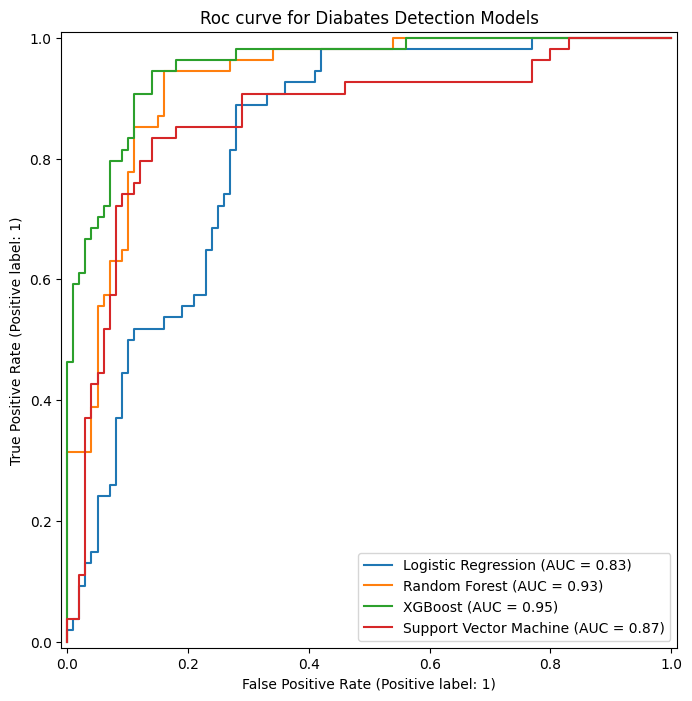

In [31]:
fig,ax=plt.subplots(figsize=(12,8))
RocCurveDisplay.from_estimator(lr,x_test_scaled,y_test,ax=ax,name='Logistic Regression')
RocCurveDisplay.from_estimator(rf,x_test_scaled,y_test,ax=ax,name='Random Forest')
RocCurveDisplay.from_estimator(xgb,x_test_scaled,y_test,ax=ax,name='XGBoost')
RocCurveDisplay.from_estimator(svm,x_test_scaled,y_test,ax=ax,name='Support Vector Machine')
ax.set_title('Roc curve for Diabates Detection Models')
plt.legend()
plt.show()

### Importanent Features for Logistic Refression Model

In [32]:
importances_lr=lr.best_estimator_.coef_[0]
feature_names=x.columns 
feature_importances_data=pd.DataFrame({'Feature':feature_names,'Importance': importances_lr})
feature_importances_data['Cofficients']=feature_importances_data['Importance'].abs()
feature_importances_data=feature_importances_data.sort_values(by='Cofficients',ascending=False)
feature_importances_data

,Feature,Importance,Cofficients
1,Glucose,0.947268,0.947268
4,Insulin,0.621576,0.621576
5,BMI,0.472393,0.472393
0,Pregnancies,0.342527,0.342527
3,SkinThickness,0.296214,0.296214
6,DiabetesPedigreeFunction,0.175632,0.175632
7,Age,0.159440,0.159440
2,BloodPressure,-0.008088,0.008088


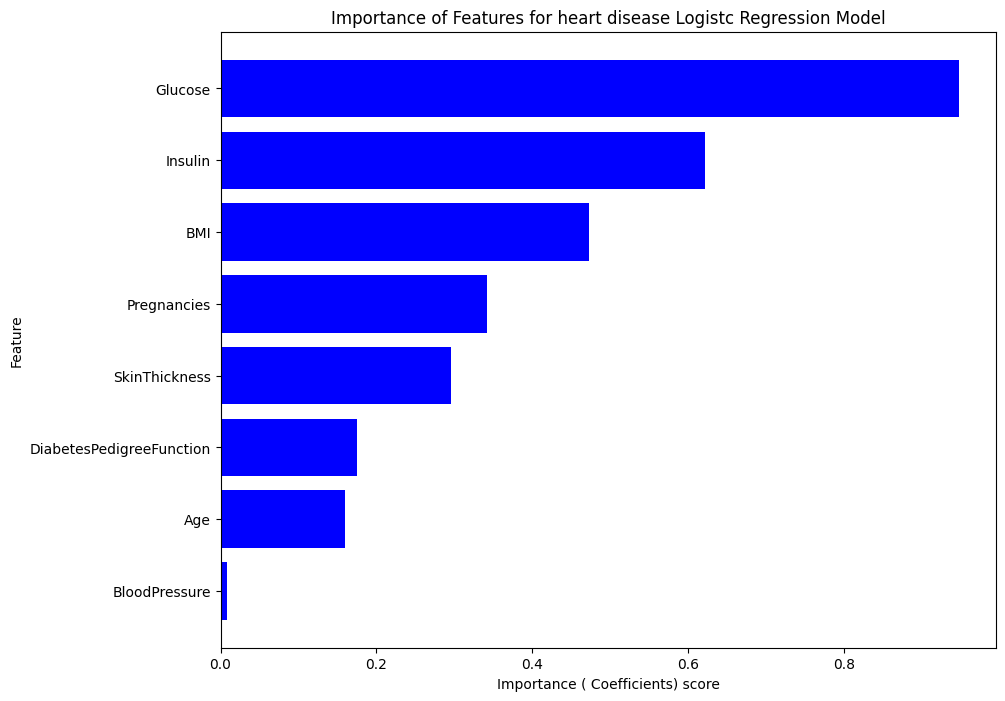

In [33]:
plt.figure(figsize=(10,8))
plt.barh(feature_importances_data['Feature'],feature_importances_data['Cofficients'],color='blue')
plt.xlabel('Importance ( Coefficients) score')
plt.ylabel('Feature')
plt.title('Importance of Features for heart disease Logistc Regression Model')
plt.gca().invert_yaxis()
plt.show()

### Important Features for Random Forest Model

In [34]:
Importance_rf=rf.best_estimator_.feature_importances_ 
feature_importances_rf=pd.DataFrame({'Feature':feature_names,'Importance':Importance_rf})
feature_importances_rf=feature_importances_rf.sort_values(by='Importance',ascending=False)
feature_importances_rf

,Feature,Importance
4,Insulin,0.432745
1,Glucose,0.201625
3,SkinThickness,0.163184
5,BMI,0.073947
7,Age,0.060039
6,DiabetesPedigreeFunction,0.026920
0,Pregnancies,0.024718
2,BloodPressure,0.016823


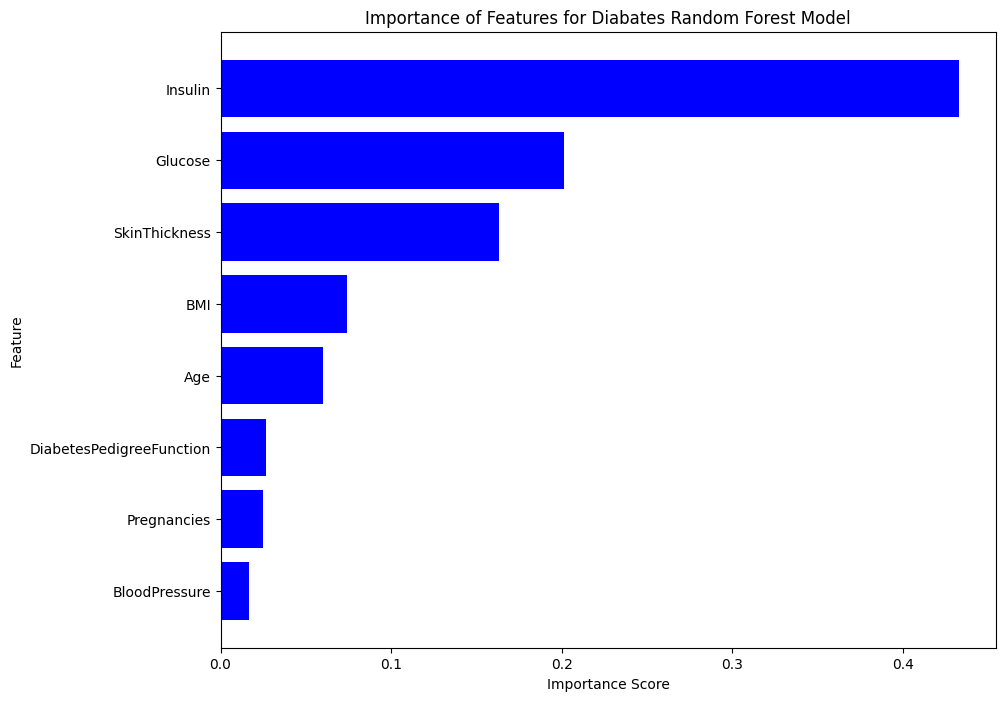

In [35]:
plt.figure(figsize=(10,8))
plt.barh(feature_importances_rf['Feature'],feature_importances_rf['Importance'],color='blue')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Importance of Features for Diabates Random Forest Model')
plt.gca().invert_yaxis()
plt.show()

### Feature Importances For XGBoost Model

In [36]:
feature_importance_xgbb=xgb.best_estimator_.feature_importances_ 
feature_importance_xgb=pd.DataFrame({'Feature':feature_names,'Importance':feature_importance_xgbb})
feature_importance_xgb=feature_importance_xgb.sort_values(by='Importance',ascending=False)
feature_importance_xgb

,Feature,Importance
4,Insulin,0.400674
1,Glucose,0.119017
3,SkinThickness,0.118341
7,Age,0.114904
5,BMI,0.073261
2,BloodPressure,0.062343
6,DiabetesPedigreeFunction,0.059713
0,Pregnancies,0.051749


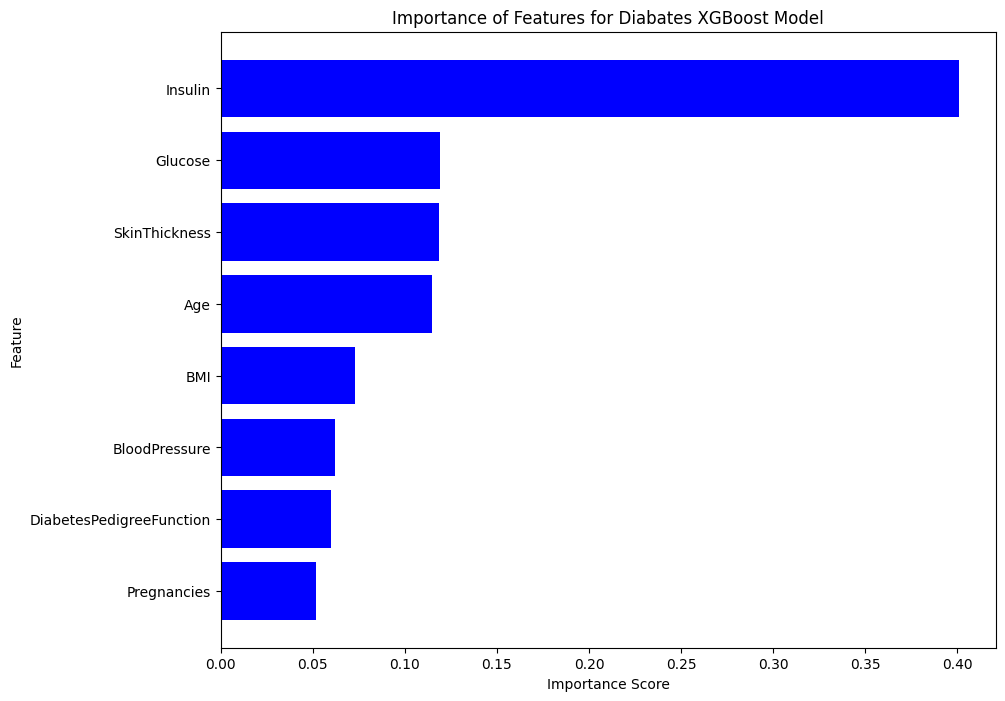

In [37]:
plt.figure(figsize=(10,8))
plt.barh(feature_importance_xgb['Feature'],feature_importance_xgb['Importance'],color='blue')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Importance of Features for Diabates XGBoost Model')
plt.gca().invert_yaxis()
plt.show()

### Importance for Features Support Vector Machine Model

In [38]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(svm, x_test_scaled, y_test, n_repeats=30, random_state=42, scoring='recall')

feature_importance_svm = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm.importances_mean
}).sort_values(by='Importance', ascending=False)

print(feature_importance_svm)

                    Feature  Importance
4                   Insulin    0.275309
3             SkinThickness    0.038889
1                   Glucose    0.022840
0               Pregnancies    0.014198
5                       BMI    0.012346
7                       Age    0.008025
2             BloodPressure   -0.016049
6  DiabetesPedigreeFunction   -0.027778


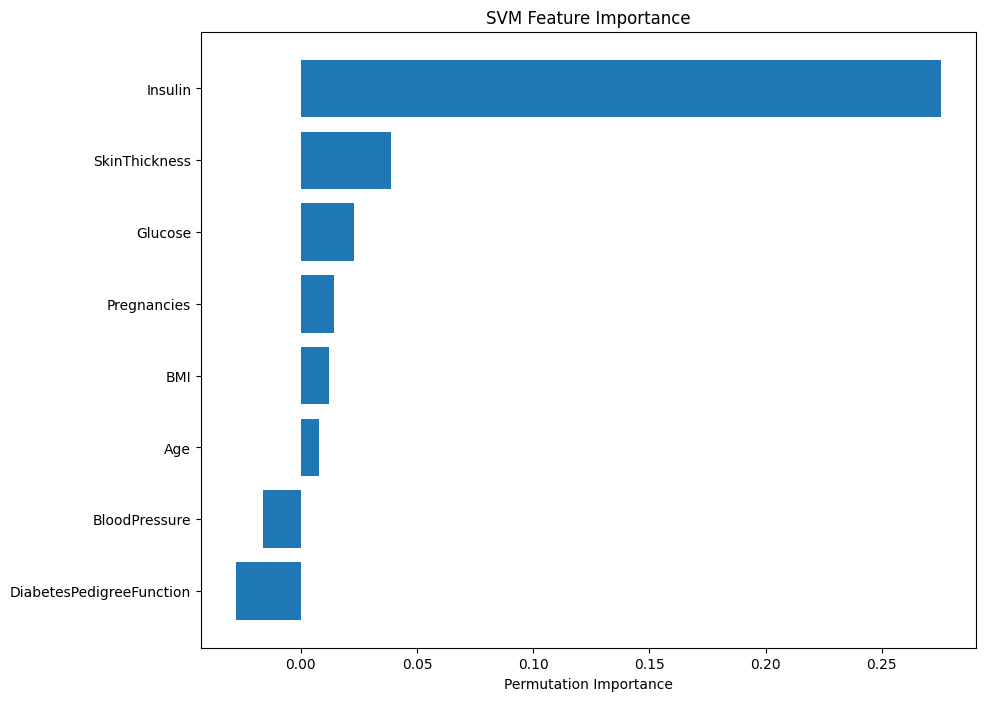

In [39]:
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_svm['Feature'], feature_importance_svm['Importance'])
plt.xlabel('Permutation Importance')
plt.title('SVM Feature Importance')
plt.gca().invert_yaxis()
plt.show()

In [40]:
models = {
    'Logistic Regression': (lr, lr_pred),
    'Random Forest': (rf, rf_pred),
    'XGBoost': (xgb, xgb_pred),
    'Support Vector Machine': (svm, svm_pred)
}

results = []
for name, (model, pred) in models.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, model.predict_proba(x_test_scaled)[:,1])
    })

results_df = pd.DataFrame(results).set_index('Model').round(3)
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.708,0.588,0.556,0.571,0.826
Random Forest,0.857,0.758,0.870,0.810,0.925
XGBoost,0.877,0.830,0.815,0.822,0.953
Support Vector Machine,0.851,0.816,0.741,0.777,0.867


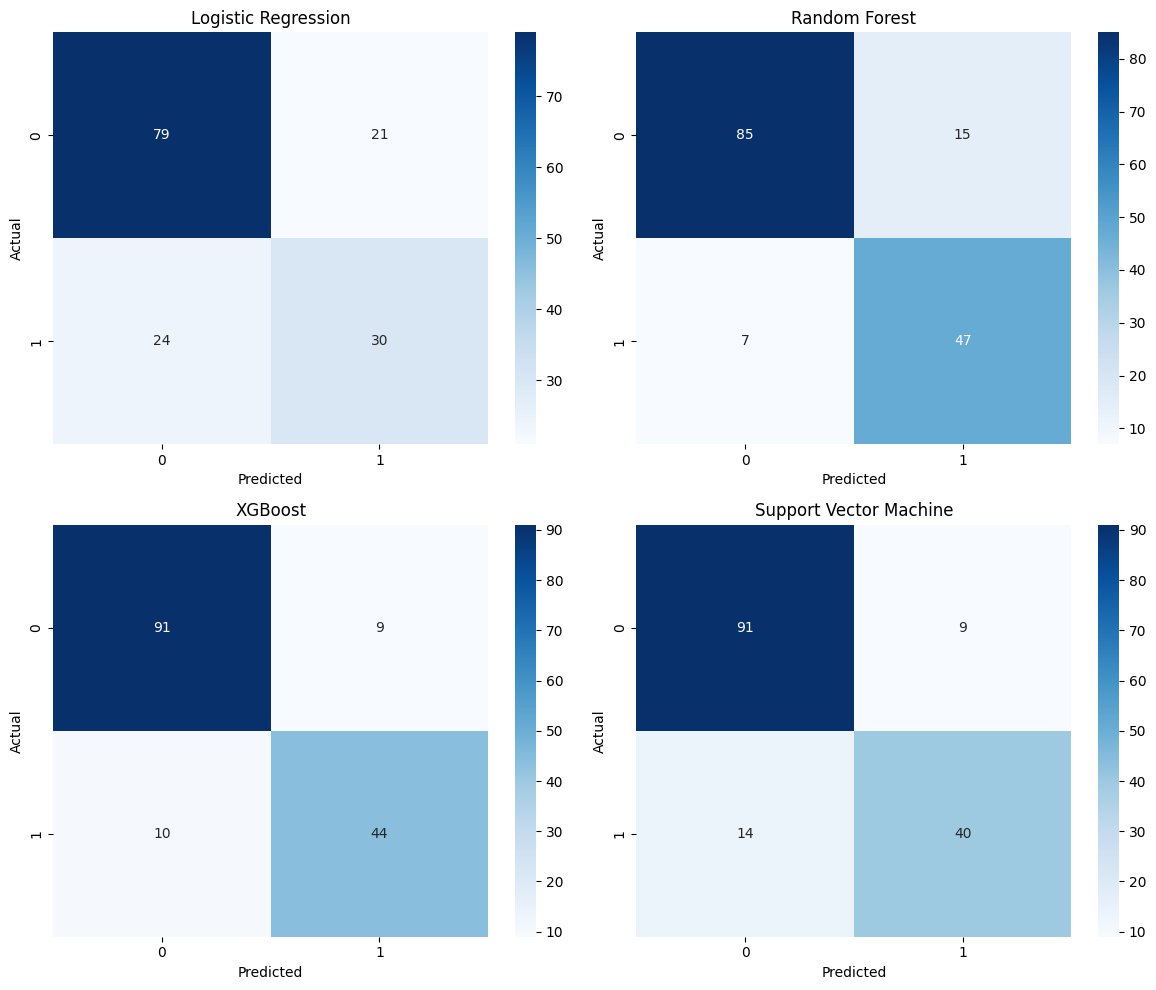

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, (model, pred)) in enumerate(models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues')
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [42]:
import joblib

joblib.dump(rf, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [43]:
import streamlit 

In [45]:
%pip install streamlit

Note: you may need to restart the kernel to use updated packages.
